In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import sys
sys.path.append('/mnt/data/yuhongyao/paper_codes/difftext/SAMA')

sys.path.append('/mnt/data/yuhongyao/paper_codes/difftext/SAMA/attack')

from attack.misc.models import ModelManager

model_path = tokenizer_path = "/mnt/data/yuhongyao/paper_codes/difftext/SAMA/outputs/LLaDA-8B-Base-pretrained-mimir-github-4_12_1.0e-5_10_512"
ref_model_path  = "GSAI-ML/LLaDA-8B-Base"
device = "cuda"


import json
def _load_dataset(name):
    path = os.path.join(model_path, f"{name}_subset.json")
    with open(path, "r") as f:
        data = json.load(f)
    return data["data"]["text"]

train_data = _load_dataset("train")
test_data = _load_dataset("test")

ModelManager.register_custom_models()
model, tokinzier, _ = ModelManager.init_model(model_path, tokenizer_path, device, None)
ref_model, _, _ = ModelManager.init_model(ref_model_path, ref_model_path, device, None)
shift_logits, mask_id = ModelManager.get_model_nll_params(model)

/mnt/data/yuhongyao/miniconda3/envs/pt410/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/mnt/data/yuhongyao/miniconda3/envs/pt410/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:


text = train_data[0]
input_ids = tokinzier.encode(text, return_tensors="pt").to(device)
input_ids.shape

torch.Size([1, 219])

In [4]:
max_t = 20
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import time
import seaborn as sns
import matplotlib.pyplot as plt

mask_num = 20

cum_cnt = torch.zeros_like(input_ids)
cum_logits = torch.zeros_like(input_ids, dtype=torch.float)
cum_ref_logits = torch.zeros_like(input_ids, dtype=torch.float)
cum_win_logits = torch.zeros_like(input_ids)

cum_prob = torch.zeros_like(input_ids, dtype=torch.float)
cum_ref_prob = torch.zeros_like(input_ids, dtype=torch.float)
cum_win_prob = torch.zeros_like(input_ids)
from tqdm import tqdm

for it in tqdm(range(100)):
    masked_input_ids = input_ids.clone()
    # random mask mask_num tokens
    mask_indices = torch.randperm(input_ids.shape[1])[:mask_num]
    masked_input_ids[:, mask_indices] = mask_id
    cum_cnt[:, mask_indices] += 1

    with torch.no_grad():
        logits = model(input_ids=masked_input_ids).logits
        ref_logits = ref_model(input_ids=masked_input_ids).logits
        prob = F.softmax(logits, dim=-1)
        ref_prob = F.softmax(ref_logits, dim=-1)

        label_logits = logits.gather(
            dim=-1, index=input_ids.unsqueeze(-1)
        ).squeeze(-1)
        label_ref_logits = ref_logits.gather(
            dim=-1, index=input_ids.unsqueeze(-1)
        ).squeeze(-1)
        if it == 0:
            print(label_logits.shape, label_ref_logits.shape)
            # break
        label_win_logits = label_logits > label_ref_logits
        label_prob = prob.gather(
            dim=-1, index=input_ids.unsqueeze(-1)
        ).squeeze(-1)
        label_ref_prob = ref_prob.gather(
            dim=-1, index=input_ids.unsqueeze(-1)
        ).squeeze(-1)
        label_win_prob = label_prob > label_ref_prob

        cum_logits[:, mask_indices] += label_logits[:, mask_indices]
        cum_ref_logits[:, mask_indices] += label_ref_logits[:, mask_indices]

        cum_prob[:, mask_indices] += label_prob[:, mask_indices]
        cum_ref_prob[:, mask_indices] += label_ref_prob[:, mask_indices]

        cum_win_logits[:, mask_indices] += label_win_logits[:, mask_indices]
        cum_win_prob[:, mask_indices] += label_win_prob[:, mask_indices]
        cum_cnt[:, mask_indices] += 1

    del logits, ref_logits, prob, ref_prob
    torch.cuda.empty_cache()

mean_logits = cum_logits / cum_cnt
mean_ref_logits = cum_ref_logits / cum_cnt

mean_prob = cum_prob / cum_cnt
mean_ref_prob = cum_ref_prob / cum_cnt

mean_win_logits = cum_win_logits.float() / cum_cnt
mean_win_prob = cum_win_prob.float() / cum_cnt

full_mask_input_ids = torch.ones_like(input_ids) * mask_id
with torch.no_grad():
    logits = model(input_ids=full_mask_input_ids).logits
    prob = F.softmax(logits, dim=-1)
    ref_logits = ref_model(input_ids=full_mask_input_ids).logits
    ref_prob = F.softmax(logits, dim=-1)

    logits = logits.gather(-1, input_ids.unsqueeze(-1)).squeeze(-1)
    prob = prob.gather(-1, input_ids.unsqueeze(-1)).squeeze(-1)
    ref_logits = ref_logits.gather(-1, input_ids.unsqueeze(-1)).squeeze(-1)
    ref_prob = ref_prob.gather(-1, input_ids.unsqueeze(-1)).squeeze(-1)



  2%|▏         | 2/100 [00:00<00:37,  2.60it/s]

torch.Size([1, 219]) torch.Size([1, 219])


100%|██████████| 100/100 [00:13<00:00,  7.57it/s]


In [5]:
save_object = {
    "prediction": {
        "logits": mean_logits.float().cpu().numpy(),
        "ref_logits": mean_ref_logits.float().cpu().numpy(),
        "prob": mean_prob.float().cpu().numpy(),
        "ref_prob": mean_ref_prob.float().cpu().numpy(),
        "win_logits": mean_win_logits.float().cpu().numpy(),
        "win_prob": mean_win_prob.float().cpu().numpy(),
    },
    "cnt": cum_cnt.cpu().numpy(),
    "fullmask": {
        "logits": logits.float().cpu().numpy(),
        "ref_logits": ref_logits.float().cpu().numpy(),
        "prob": prob.float().cpu().numpy(),
        "ref_prob": ref_prob.float().cpu().numpy(),
    }
}

In [6]:
save_dir = "test/statics1/train"
os.makedirs(save_dir, exist_ok=True)
save_name = os.path.join(save_dir, f"0.pt")
torch.save(save_object, save_name)

del ref_model, model

In [1]:
import torch
import os
save_dir = "test/statics1/train"
os.makedirs(save_dir, exist_ok=True)
save_name = os.path.join(save_dir, f"0.pt")
data = torch.load(save_name)
data.keys()

/mnt/data/yuhongyao/miniconda3/envs/pt410/lib/python3.10/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/tmp/ipykernel_358010/1798767029.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by t

dict_keys(['prediction', 'cnt', 'fullmask'])

In [2]:
import matplotlib.pyplot as plt

data['prediction']['win_prob'].shape

(1, 219)

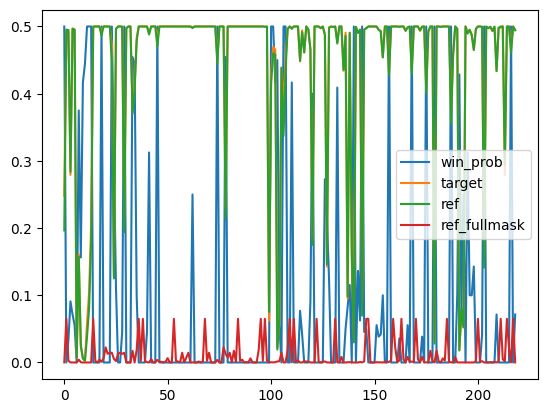

In [9]:
plt.plot(data['prediction']['win_prob'][0], label="win_prob")
plt.plot(data['prediction']['prob'][0], label="target")
plt.plot(data['prediction']['ref_prob'][0], label="ref")
plt.plot(data['fullmask']['ref_prob'][0], label="ref_fullmask")
plt.legend()
plt.show()

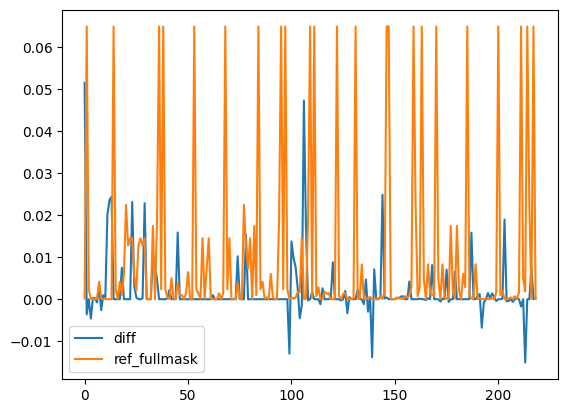

In [3]:
f = lambda x: x # np.log(x + 1e-10)

# plt.plot(f(data['prediction']['win_prob'][0]), label="win_prob")
plt.plot(f(data['prediction']['prob'][0]) - f(data['prediction']['ref_prob'][0]), label="diff")
# plt.plot(, label="ref")
plt.plot(f(data['fullmask']['ref_prob'][0]), label="ref_fullmask")
plt.legend()
plt.show()

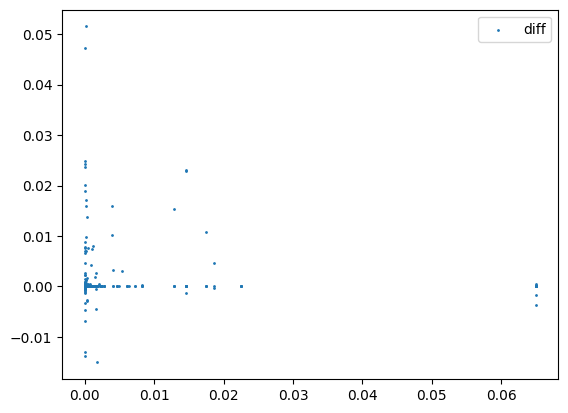

In [18]:

import numpy as np
f1 = lambda x: x # np.log(x + 1e-10)
f2 = lambda x:  x

# plt.plot(f(data['prediction']['win_prob'][0]), label="win_prob")
x = f1(data['fullmask']['ref_prob'][0])
y = f2(data['prediction']['prob'][0]) - f2(data['prediction']['ref_prob'][0])
plt.scatter(x, y, label="diff", s=1)
# plt.plot(, label="ref")
# plt.plot(, label="ref_fullmask")
plt.legend()
plt.show()

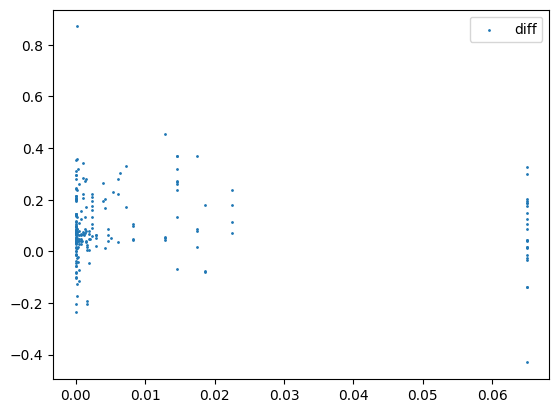

In [34]:

import numpy as np
f1 = lambda x: x #  np.log(x + 1e-10)
f2 = lambda x:  x

# plt.plot(f(data['prediction']['win_prob'][0]), label="win_prob")
x = f1(data['fullmask']['ref_prob'][0])
y = f2(data['prediction']['logits'][0]) - f2(data['prediction']['ref_logits'][0])
plt.scatter(x, y, label="diff", s=1)
# plt.plot(, label="ref")
# plt.plot(, label="ref_fullmask")
plt.legend()
plt.show()